In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [2]:
# -----------------------------
# 1. Create a simple dataset
# -----------------------------
class SequenceDataset(Dataset):
    def __init__(self, seq_length=3, total_samples=1000):
        self.seq_length = seq_length
        self.data = []
        for i in range(total_samples):
            start = np.random.randint(0, 100)
            seq = np.arange(start, start + seq_length + 1)
            self.data.append((seq[:-1], seq[-1]))  # (input, target)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq, target = self.data[idx]
        return torch.tensor(seq, dtype=torch.float32).unsqueeze(-1), torch.tensor(target, dtype=torch.float32)


In [3]:
# -----------------------------
# 2. Define a simple GRU model
# -----------------------------
class GRUPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(GRUPredictor, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)        # out: [batch_size, seq_len, hidden]
        out = out[:, -1, :]         # take the last time step
        out = self.fc(out)          # map to output
        return out.squeeze()

In [8]:
# -----------------------------
# 3. Training setup
# -----------------------------
def train():
    dataset = SequenceDataset(seq_length=3, total_samples=1000)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    model = GRUPredictor()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(100):
        total_loss = 0
        for seq, target in dataloader:
            output = model(seq)
            loss = criterion(output, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [ ]:
# -----------------------------
# 5. Test the trained model
# -----------------------------
def test(model):
    model.eval()
    test_seqs = [
        [20, 21, 22],  # Should predict ~23
        [99, 100, 101],  # Should predict ~102
        [5, 6, 7],  # Should predict ~8
    ]

    for seq in test_seqs:
        input_seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # [1, seq_len, 1]
        with torch.no_grad():
            prediction = model(input_seq).item()
        print(f"Input: {seq} → Predicted next: {prediction:.2f} (Expected: {seq[-1] + 1})")

In [9]:
trained_model = train()
print("\n🧪 Testing the trained GRU model:")
test(trained_model)

Epoch 1, Loss: 104084.4714
Epoch 2, Loss: 76997.9038
Epoch 3, Loss: 56705.0562
Epoch 4, Loss: 42840.5475
Epoch 5, Loss: 30848.6025
Epoch 6, Loss: 22984.1671
Epoch 7, Loss: 17212.6059
Epoch 8, Loss: 12884.3213
Epoch 9, Loss: 9463.7210
Epoch 10, Loss: 7205.3969
Epoch 11, Loss: 5612.1880
Epoch 12, Loss: 4113.7910
Epoch 13, Loss: 3261.8304
Epoch 14, Loss: 2556.8324
Epoch 15, Loss: 1949.1583
Epoch 16, Loss: 1564.6780
Epoch 17, Loss: 1342.5632
Epoch 18, Loss: 1032.4616
Epoch 19, Loss: 885.0776
Epoch 20, Loss: 695.1435
Epoch 21, Loss: 610.3716
Epoch 22, Loss: 530.0295
Epoch 23, Loss: 456.7233
Epoch 24, Loss: 386.7089
Epoch 25, Loss: 311.9483
Epoch 26, Loss: 253.0142
Epoch 27, Loss: 234.3990
Epoch 28, Loss: 185.4183
Epoch 29, Loss: 167.4883
Epoch 30, Loss: 149.7455
Epoch 31, Loss: 127.4698
Epoch 32, Loss: 110.9339
Epoch 33, Loss: 95.8129
Epoch 34, Loss: 80.3229
Epoch 35, Loss: 75.6346
Epoch 36, Loss: 106.2212
Epoch 37, Loss: 70.9238
Epoch 38, Loss: 61.1186
Epoch 39, Loss: 51.1968
Epoch 40, Los

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

# -----------------------------
# 1. Simulated video dataset
# -----------------------------
class SimulatedVideoDataset(Dataset):
    def __init__(self, num_identities=5, seq_len=10, num_samples=1000, feature_dim=64):
        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.samples = []
        for _ in range(num_samples):
            label = random.randint(0, num_identities - 1)
            base = np.random.randn(feature_dim) + label * 3.0  # identity-specific pattern
            sequence = base + 0.1 * np.random.randn(seq_len, feature_dim)  # add temporal noise
            self.samples.append((sequence, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, label = self.samples[idx]
        return torch.tensor(seq, dtype=torch.float32), label

# -----------------------------
# 2. GRU model for classification
# -----------------------------
class GRUClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_classes=5):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        _, h_n = self.gru(x)           # h_n: [1, batch, hidden_dim]
        embedding = h_n.squeeze(0)     # [batch, hidden_dim]
        out = self.classifier(embedding)
        return out

# -----------------------------
# 3. Training the model
# -----------------------------
def train_model():
    dataset = SimulatedVideoDataset()
    print(f"Dataset size: {len(dataset)} samples")
    print(f"Sample shape: {dataset[0][0].shape} (sequence length: {dataset[0][0].shape[0]}, feature dim: {dataset[0][0].shape[1]})")
    print(f"Label: {dataset[0][1]} (identity)")
    print(f"Number of identities: {len(set(label for _, label in dataset))}")
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    model = GRUClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(10):
        total_loss = 0
        correct = 0
        for batch_x, batch_y in loader:
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (logits.argmax(dim=1) == batch_y).sum().item()

        acc = correct / len(dataset)
        print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}, Accuracy = {acc:.2%}")
    
    return model

# -----------------------------
# 4. Simple test function
# -----------------------------
def test_model(model):
    test_seq = torch.randn(1, 10, 64) + 3 * 2  # simulate person 2
    print(test_seq.shape)
    print(f"Test sequence shape: {test_seq.shape}")
    with torch.no_grad():
        logits = model(test_seq)
        pred = logits.argmax(dim=1).item()
    print(f"\nPredicted Identity: {pred}")

# -----------------------------
# 5. Run everything
# -----------------------------
if __name__ == "__main__":
    trained_model = train_model()
    test_model(trained_model)


Dataset size: 1000 samples
Sample shape: torch.Size([10, 64]) (sequence length: 10, feature dim: 64)
Label: 0 (identity)
Number of identities: 5
Epoch 1: Loss = 33.0938, Accuracy = 69.70%
Epoch 2: Loss = 13.9438, Accuracy = 97.50%
Epoch 3: Loss = 4.7695, Accuracy = 100.00%
Epoch 4: Loss = 2.6821, Accuracy = 99.80%
Epoch 5: Loss = 1.2739, Accuracy = 100.00%
Epoch 6: Loss = 0.8262, Accuracy = 100.00%
Epoch 7: Loss = 0.6184, Accuracy = 100.00%
Epoch 8: Loss = 0.4730, Accuracy = 100.00%
Epoch 9: Loss = 0.3814, Accuracy = 100.00%
Epoch 10: Loss = 0.3129, Accuracy = 100.00%
torch.Size([1, 10, 64])
Test sequence shape: torch.Size([1, 10, 64])

Predicted Identity: 2


🔍 Sequence shape: torch.Size([1, 10, 64])
🔍 Label: 3


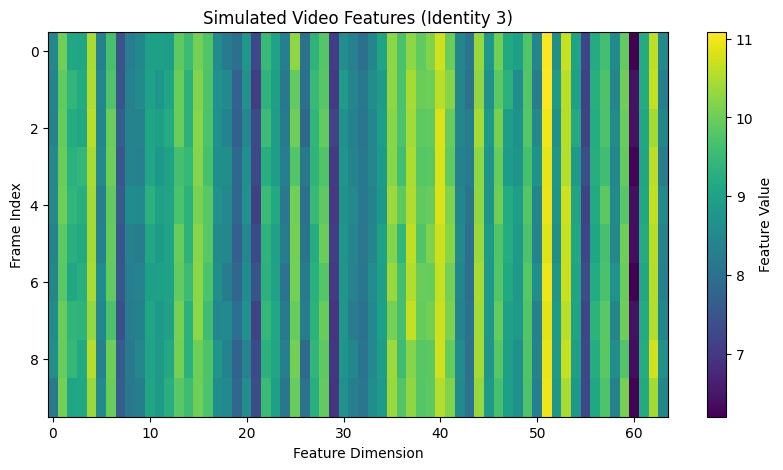

In [12]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Load the dataset
dataset = SimulatedVideoDataset(num_identities=5, seq_len=10, num_samples=1000, feature_dim=64)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# Get one sample
sample_seq, sample_label = next(iter(dataloader))

print("🔍 Sequence shape:", sample_seq.shape)  # [1, seq_len, feature_dim]
print("🔍 Label:", sample_label.item())

# Squeeze batch dimension: [1, 10, 64] → [10, 64]
sequence = sample_seq.squeeze(0).numpy()

# Plot as heatmap: rows = frames, columns = features
plt.figure(figsize=(10, 5))
plt.title(f"Simulated Video Features (Identity {sample_label.item()})")
plt.imshow(sequence, aspect='auto', cmap='viridis')
plt.colorbar(label="Feature Value")
plt.xlabel("Feature Dimension")
plt.ylabel("Frame Index")
plt.show()


In [14]:
import torchvision.models as models
resnet = models.resnet50(pretrained=True)

# Remove the final classification layer
features = resnet.avgpool  # shape: [B, 2048, 1, 1]


/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
